# Adversarial Attacks

In this notebook, we will be exploring the world of adversarial attacks, where even minor modifications to the input data can cause machine learning models to make incorrect predictions. These attacks illustrate the potential vulnerabilities in systems that rely on machine learning, which raises concerns in fields such as autonomous vehicles. For example, a self-driving car could misinterpret a slightly altered stop sign. We will learn how to create adversarial examples ourselves using the Fast Gradient Sign Method (FGSM).

__Step 1:__ Load the required libraries.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow  as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Softmax
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image

# You can add more imports if necessary

:bell: You are free to add any library you deem necessary to successfully complete this homework assignment!  

For this tutorial, we will again use the Cats vs. Dogs dataset, which consists of images featuring the two distinct animal classes. To make data preprocessing easier, we have already organized the images into separate folders. You will find a 'train' folder containing images used to train your model and a 'test' folder with images for evaluating your model's performance. You can download the preprocessed dataset, [here](https://edubuas-my.sharepoint.com/:f:/g/personal/blerck_i_buas_nl/Egas9AxZzg1MrAE8f8RtErwB1Xy1CKhaNiHQX9hJjTT4Ew?e=WbD2Md). 

__Step 2:__ Download the Cats vs. Dogs dataset, and and assign the paths to the train and test set folders to the variables ```src_path_train``` and ```src_path_train```. 

In [2]:
src_path_cats = 'C:\\Users\\USER\\Desktop\\cats'
src_path_dogs = 'C:\\Users\\USER\\Desktop\\dogs'

__Step 3:__ Pre-process your data: 

- Rescale the images to have pixel values between 0 and 1.
- Resize the images to 224x224 pixels.
- Ensure that the images are in the correct format (e.g., RGB).
- One-hot encode the labels.
- Apply other preprocessing steps, such as horizontal flip and zoom, as necessary. 

In [3]:
def load_and_preprocess_images(src_path, label):
    images = []
    labels = []
    for filename in os.listdir(src_path):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img = Image.open(os.path.join(src_path, filename))
            img = img.resize((224, 224))  
            img = np.array(img) / 255.0
            if len(img.shape) == 2:
                img = np.stack((img,) * 3, axis=-1)
            images.append(img)
            labels.append(label)
    return images, labels

# Load and preprocess images
images_cats, labels_cats = load_and_preprocess_images(src_path_cats, 0)
images_dogs, labels_dogs = load_and_preprocess_images(src_path_dogs, 1)

# Combine cats and dogs
images = images_cats + images_dogs
labels = labels_cats + labels_dogs

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# One-hot encode labels
labels = to_categorical(labels)

__Step 4:__ Split your dataset into an 80% training set, 10% validation set, and 10% test set, and assign the sets to the following variables as a numpy array: ```X_train```, ```X_val```, ```X_test```, ```y_train```, ```y_val```, and ```y_test```.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

__Step 5:__ Design a Sequential model using the Keras API. Include at least one Conv2D layer for feature extraction, a Flatten layer to prepare the data for classification, and two Dense layers. Leave the second-to-last Dense layer without an activation function, but apply a softmax activation to the final output layer.

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense

# Define the model
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3), activation='relu'))

model.add(Flatten())

model.add(Dense(64))

model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 flatten_3 (Flatten)         (None, 1577088)           0         
                                                                 
 dense_6 (Dense)             (None, 64)                100933696 
                                                                 
 dense_7 (Dense)             (None, 2)                 130       
                                                                 
Total params: 100,934,722
Trainable params: 100,934,722
Non-trainable params: 0
_________________________________________________________________


__Step 6:__ Compile your model, and train it using the training and validation sets.

In [9]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=32)

Epoch 1/5
75/75 [==============================] - 38s 490ms/step - loss: 35.7028 - accuracy: 0.5471 - val_loss: 0.7931 - val_accuracy: 0.6233
Epoch 2/5
75/75 [==============================] - 38s 505ms/step - loss: 0.5369 - accuracy: 0.7542 - val_loss: 0.9725 - val_accuracy: 0.6300
Epoch 3/5
75/75 [==============================] - 53s 702ms/step - loss: 0.2591 - accuracy: 0.9050 - val_loss: 0.9612 - val_accuracy: 0.6100
Epoch 4/5
75/75 [==============================] - 77s 1s/step - loss: 0.1007 - accuracy: 0.9737 - val_loss: 1.0898 - val_accuracy: 0.6200
Epoch 5/5
75/75 [==============================] - 100s 1s/step - loss: 0.0514 - accuracy: 0.9925 - val_loss: 2.6725 - val_accuracy: 0.5100


__Step 7:__ Load your chosen test image into a NumPy array by setting the index (e.g., ```img = X_test[4]```). Since many XAI techniques expect data in batches, we need to slightly reshape our image to add a batch dimension, even though we are only working with a single image. Use Numpy's [expand_dims()](https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html) method to add a new dimension at the beginning of your image array. This new dimension represents our batch size of 1, transforming the shape of the array from (224, 224, 3) to (1, 224, 224, 3). Assign the transformed image array to the variable ```img_batch```.  

In [10]:
# Load the test image into a numpy array
img = X_test[4]

# Add a new dimension at the beginning of the image array
img_batch = np.expand_dims(img, axis=0)

__Step 8:__ Use your trained model to generate a prediction for the *__original version__* of the chosen image. This prediction be two probabilities (one for each class), in the form of a Numpy array that sum up to 1. Determine which of these two probabilities is higher: The class with the higher probability is the model's initial prediction. Then, save the index of the class with the higher probability in the variable ```initial_class```. Since you only have two classes, this index will be either 0 or 1.

In [23]:
# Generate a prediction for the original version of the image
predictions_original = model.predict(img_batch)

# Determine the initial class
initial_class = np.argmax(predictions_original[0])
print(predictions_original)

1/1 [==============================] - 0s 80ms/step
[[3.4988986e-06 9.9999654e-01]]


__Step 9:__ Generate the adversarial pattern, and apply the perturbations to the chosen test image by running the next code block. You may adjust the epsilon to change the level of the adversarial perturbation that is added to the original image. 

:bell: If you do not see a heatmap, the vanishing gradient problem might be the culprit. To investigate further, uncomment the ```tf.print(gradient, summarize=-1)``` line within the code block, to see the gradients. For more information on the vanishing gradient problem, see Thursday's independent study material of week 6. 

In [21]:
def create_adversarial_pattern(input_image, input_label):
    input_image = tf.convert_to_tensor(input_image)
    input_label = tf.convert_to_tensor(input_label)

    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = model(input_image)
        loss = tf.keras.losses.categorical_crossentropy(input_label, prediction)
    gradient = tape.gradient(loss, input_image)
    tf.print(gradient, summarize=-1) # Prints all the gradients
    signed_gradient = tf.sign(gradient)
    return signed_gradient

label = np.array(predictions_original)

perturbations = create_adversarial_pattern(img_batch, label)
epsilon = 0.3 # Adjust epsilon as needed

img_adversarial = img_batch + epsilon * perturbations
img_adversarial = tf.clip_by_value(img_adversarial, 0, 1)

# Add this to visualize the adversarial image
# plt.imshow(img_adversarial[0])
# plt.show()

[[[[0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]
   [0 0 0]

__Step 10:__ Use your trained model to generate a prediction for the *__adversarial version__* of the chosen image. This prediction be two probabilities (one for each class), in the form of a Numpy array that sum up to 1. Determine which of these two probabilities is higher: The class with the higher probability is the model's initial prediction. Then, save the index of the class with the higher probability in the variable ```adversarial_class```. Since you only have two classes, this index will be either 0 or 1.

In [24]:
# Generate a prediction for the adversarial version of the image
predictions_adversarial = model.predict(img_adversarial)

# Determine the adversarial class
adversarial_class = np.argmax(predictions_adversarial[0])

1/1 [==============================] - 0s 123ms/step


__Step 11:__ Run the next code block to visualize the original and adversarial images side-by-side, and see the model's classification results for each. 

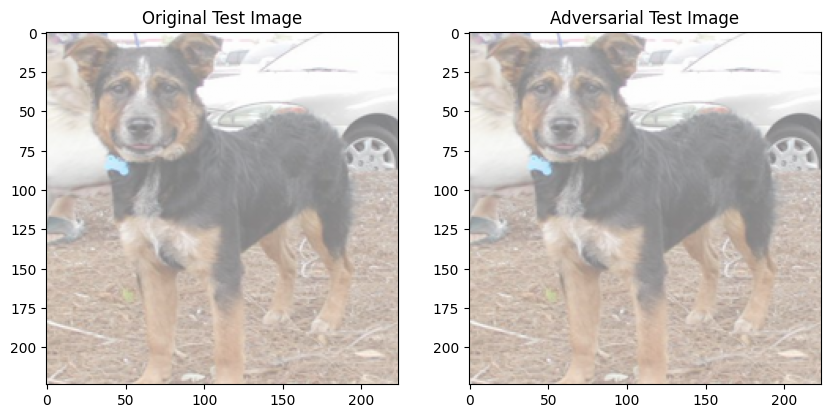

Initial prediction class: 1
[[3.4988986e-06 9.9999654e-01]]
Adversarial prediction class: 1
[[3.4988986e-06 9.9999654e-01]]


In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_batch[0] * 0.5 + 0.5)
ax[0].set_title('Original Test Image')
ax[1].imshow(img_adversarial[0] * 0.5 + 0.5)
ax[1].set_title('Adversarial Test Image')
plt.show()

print(f"Initial prediction class: {initial_class}")
print(predictions_original)
print(f"Adversarial prediction class: {adversarial_class}")
print(predictions_adversarial)